<a href="https://colab.research.google.com/github/asdiFlv3/PHAS0056_assignments/blob/main/continuous_assessments/CurveFitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def polyModel(x, theta):
  # initiate a y array
  y = np.zeros(len(x))
  # iterate through x and stops at where theta stops (can use enumerate!)
  x_i = 0
  for theta_i in theta:
    y = y + theta_i * (x ** x_i)
    x_i += 1
  return y

def polyModelWithNoise(x, theta, sigma):
  y = polyModel(x, theta)
  noise = np.random.normal(0, sigma, y.shape)
  return y + noise


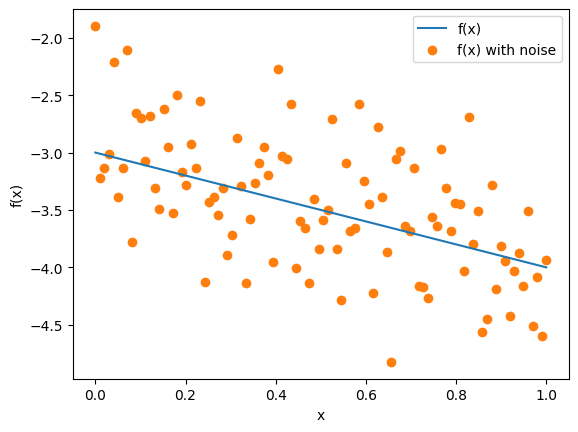

In [ ]:
x=np.linspace(0, 1, 100)
theta_true = np.array([-3, -1])
sigma = 0.5

plt.figure()
plt.plot(x, polyModel(x, theta_true))
plt.scatter(x, polyModelWithNoise(x, theta_true, sigma), c="#ff7f0e")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(["f(x)", "f(x) with noise"])
plt.show()


In [ ]:
def polyGradient(x, theta):
  # differentiate with respect to theta
  # initialize a 2D array of zeros
  # rows = number of data points (x), cols = theta, so [0,0] is x1 term diffrentiate with repect to theta 1
  grad = np.zeros((len(x), len(theta)))
  # Column 0 is x^0, Column 1 is x^1, etc.
  for i in range(len(theta)):
      grad[:, i] = x ** i
  return grad

# initialize arrays
mse_history = []
sigma_true = 0.5
learning_rate = 0.5
num_iterations = 50
start_theta = np.array([-1, 1])

def run_sgd_training(starting_theta, true_theta, sigma, learning_rate, num_steps):
  # initialize variables
  theta = starting_theta.copy() # copy to avoid modifying the original array
  mse_history = []
  for i in range(num_steps):
    x1 = np.random.rand(10)
    y_data = polyModelWithNoise(x1, true_theta, sigma)
    y_model = polyModel(x1, theta)
    # calculate difference and mse
    diff = y_model - y_data
    mse = np.mean(diff ** 2) # mse = np.mean(or average)((y_data - y_model)**2)
    # get the current gradient
    grad = polyGradient(x1, theta) # Use the local theta
    # calculate gradient of lost function, store mse
    cost_gradient = (2/(len(x1))) * np.dot(grad.T, diff)
    theta = theta - learning_rate * cost_gradient
    mse_history.append(mse)
  return theta, mse_history

final_theta, mse_linear = run_sgd_training(starting_theta=start_theta, true_theta=theta_true, sigma=sigma_true,learning_rate=learning_rate, num_steps=num_iterations)
print(final_theta)


[-3.04565693 -1.05479129]


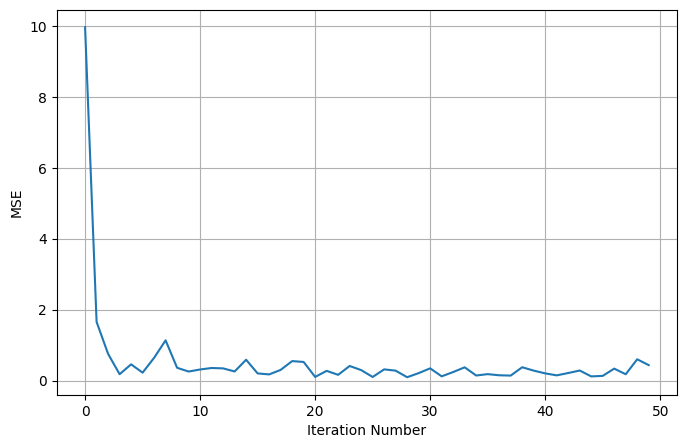

In [ ]:
# plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(len(mse_linear)), mse_linear)
plt.xlabel('Iteration Number')
plt.ylabel('MSE')
plt.grid(True)
plt.show()
'''
why is it fluctuate?
stochastic value of gradient so fluctutates.
'''

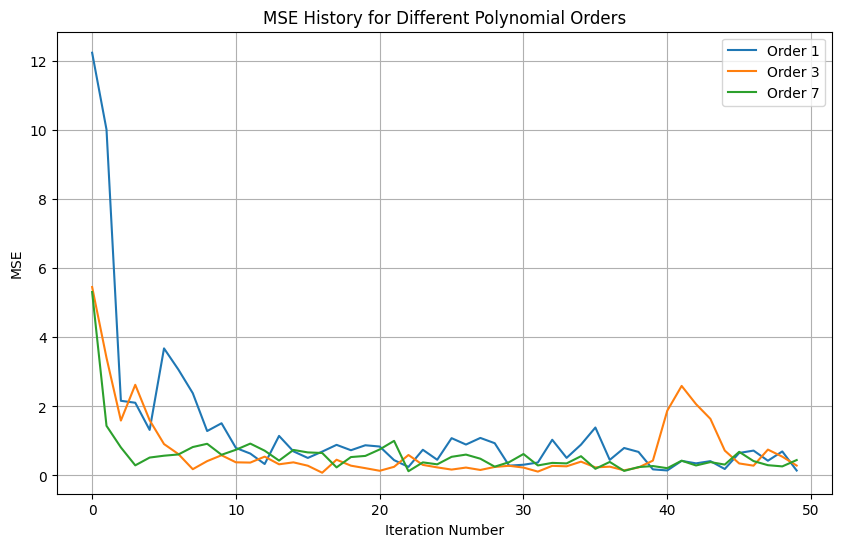

In [ ]:
# create dictionaries to hold the lists for models of the 3 orders
mse_histories = {}
final_thetas = {}
orders = [1, 3, 7]

# new parameters
theta_true_3 = np.array([-1, 2, 3, 2])
for order in orders:
  start_theta_3 = np.zeros(order + 1)

  # run training for the current order model using the function
  final_theta_for_order, mse_history_for_order = run_sgd_training(
      starting_theta=start_theta_3,
      true_theta=theta_true_3,
      sigma=sigma_true,
      learning_rate=learning_rate,
      num_steps=num_iterations
  )

  # save this list into the main dictionary
  mse_histories[order] = mse_history_for_order
  final_thetas[order] = final_theta_for_order

# plot
plt.figure(figsize=(10, 6))
for order in orders:
  plt.plot(mse_histories[order], label=f"Order {order}")

plt.xlabel('Iteration Number')
plt.ylabel('MSE')
plt.title('MSE History for Different Polynomial Orders')
plt.grid(True)
plt.legend()
plt.show()

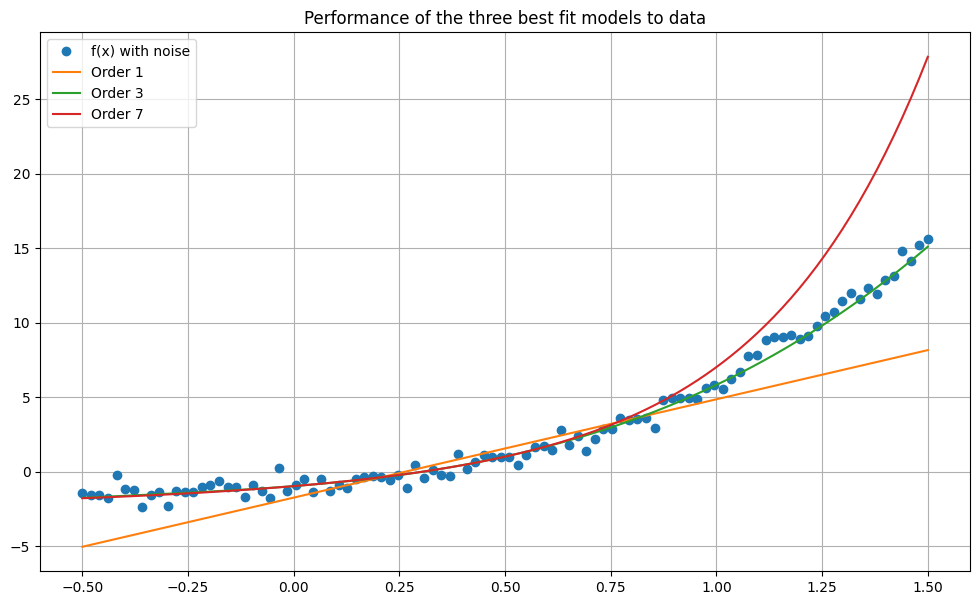

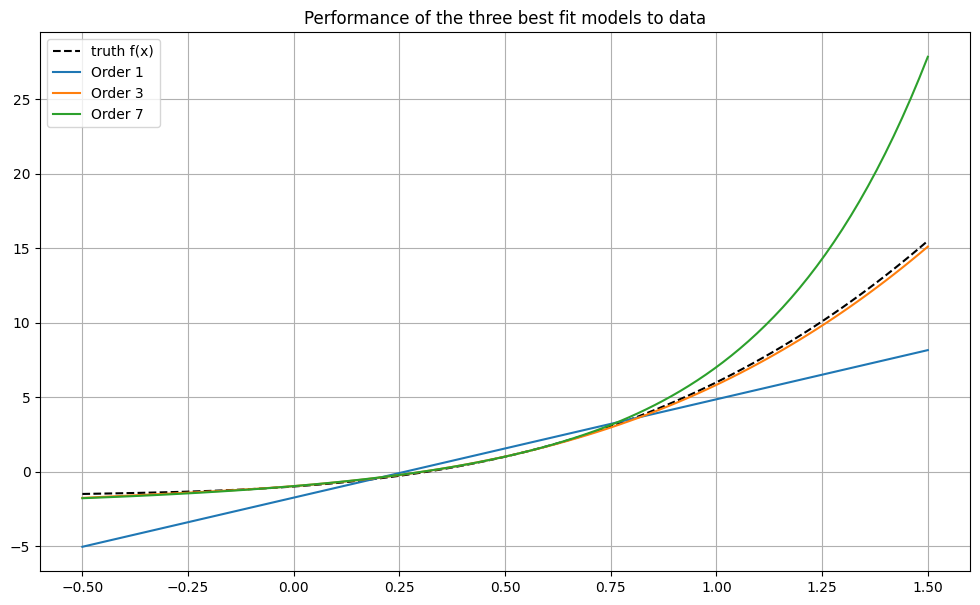

In [ ]:
x_third = np.linspace(-0.5, 1.5, 100)
y_third = polyModelWithNoise(x_third, theta_true_3, sigma_true)
y_truth = polyModel(x_third, theta_true_3)

plt.figure(figsize=(12, 7))
plt.plot(x_third, y_third, 'o', label="f(x) with noise")
#plt.plot(x_third, y_truth, "k--", label = "truth f(x)")
for order in orders:
  plt.plot(x_third, polyModel(x_third, final_thetas[order]), label=f"Order {order}")

plt.title('Performance of the three best fit models to data')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 7))
#plt.plot(x_third, y_third, 'o', label="f(x) with noise")
plt.plot(x_third, y_truth, "k--", label = "truth f(x)")
for order in orders:
  plt.plot(x_third, polyModel(x_third, final_thetas[order]), label=f"Order {order}")
plt.title('Performance of the three best fit models to data')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



## Comment

> Comment on how well the models generalise to the regions of x over which they were not trained.

Order 1 is just a straight line

The rest 2 polynomial models fit the data over which they were trained relatively well, when they went beyond known data:

- Order 3 generalized well on unseen data

- Order 7 diverges away from the black line, fails on data it hasn't seen.